## Modelo Poisson

In [1]:
# librerias
import libpysal as ps
import numpy
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn
import numpy as np
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
from shapely.geometry import Point

In [6]:
df = gpd.read_file('../data/regresion_POMCA_Final.geojson')
df['HYBAS_ID'] = df['HYBAS_ID'].astype(str)
df = df.drop(columns=['MAIN_BAS'])
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   HYBAS_ID           293 non-null    object  
 1   num_species        293 non-null    int32   
 2   num_points         293 non-null    int32   
 3   bio1_mean          293 non-null    float64 
 4   bio3_mean          293 non-null    float64 
 5   bio4_mean          293 non-null    float64 
 6   bio7_mean          293 non-null    float64 
 7   bio12_mean         293 non-null    float64 
 8   bio15_mean         293 non-null    float64 
 9   elevacion          293 non-null    float64 
 10  sp_density         293 non-null    float64 
 11  num_species_std    293 non-null    float64 
 12  w_num_species_std  293 non-null    float64 
 13  num_points_std     293 non-null    float64 
 14  w_num_points_std   293 non-null    float64 
 15  sp_density_std     293 non-null    float64 
 16  

In [7]:
df.columns
df.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [8]:
import statsmodels.api as sm
import numpy as np

# Variable dependiente (cuenta)
y = df['num_species'].values

# Variables independientes
X = df[['bio3_mean', 'bio4_mean', 'bio7_mean', 'bio12_mean', 'bio15_mean', 'elevacion', 'num_points']]

# Agregar constante para el intercepto
X = sm.add_constant(X)


In [9]:
poisson_model = sm.GLM(y, X, family=sm.families.Poisson())
poisson_results = poisson_model.fit()
print(poisson_results.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  293
Model:                            GLM   Df Residuals:                      285
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -555.74
Date:                Tue, 22 Jul 2025   Deviance:                       339.89
Time:                        21:12:52   Pearson chi2:                     369.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.5947
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.9872      1.895      5.272      0.0

In [10]:
df = df.to_crs(epsg=3116)
df['area'] = df['geometry'].area

In [11]:
import numpy as np
import statsmodels.api as sm
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod import families
from sklearn.preprocessing import StandardScaler

# Variable dependiente
y = df['num_species'].values

# Variables predictoras
vars_pred = ['bio3_mean', 'bio4_mean', 'bio7_mean', 'bio12_mean', 'bio15_mean', 'elevacion', 'num_points']
X_raw = df[vars_pred].values

# Escalar predictores
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Añadir intercepto
X = sm.add_constant(X_scaled)

# (Opcional) Offset si tienes área en km2 o similar
# df['area_km2'] = ... # Asegúrate de tener esta columna
# offset = np.log(df['area_km2'].values)
offset = np.log(df['area'])

# Modelo Poisson sin offset
# poisson_model = GLM(y, X, family=families.Poisson()).fit()

# Si tienes área y deseas usarla:
poisson_model_offset = GLM(y, X, family=families.Poisson(), offset=offset).fit()

# Resultados
print(poisson_model_offset.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  293
Model:                            GLM   Df Residuals:                      285
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -553.17
Date:                Tue, 22 Jul 2025   Deviance:                       334.76
Time:                        21:13:03   Pearson chi2:                     355.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.6579
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -18.1461      0.040   -450.320      0.0

In [14]:
df.area

0      1.947103e+08
1      1.771174e+08
2      2.147058e+08
3      2.385737e+08
4      2.179210e+08
           ...     
288    2.406892e+08
289    1.447786e+08
290    1.185299e+08
291    1.858712e+08
292    9.426030e+07
Length: 293, dtype: float64

In [12]:
import matplotlib.pyplot as plt

# Añadir las predicciones al GeoDataFrame
df['predicted_species'] = poisson_model.predict(X)

# Calcular la diferencia entre el valor real y la predicción
df['predicted_species'] = df['num_species'] - df['predicted_species']

# Graficar el mapa con los valores de predicción ajustados por área
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
df.plot(column='predicted_species', cmap='YlGnBu',
             linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

ax.set_title('Mapa de Predicción de Riqueza', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

ValueError: shapes (293,8) and (293,8) not aligned: 8 (dim 1) != 293 (dim 0)

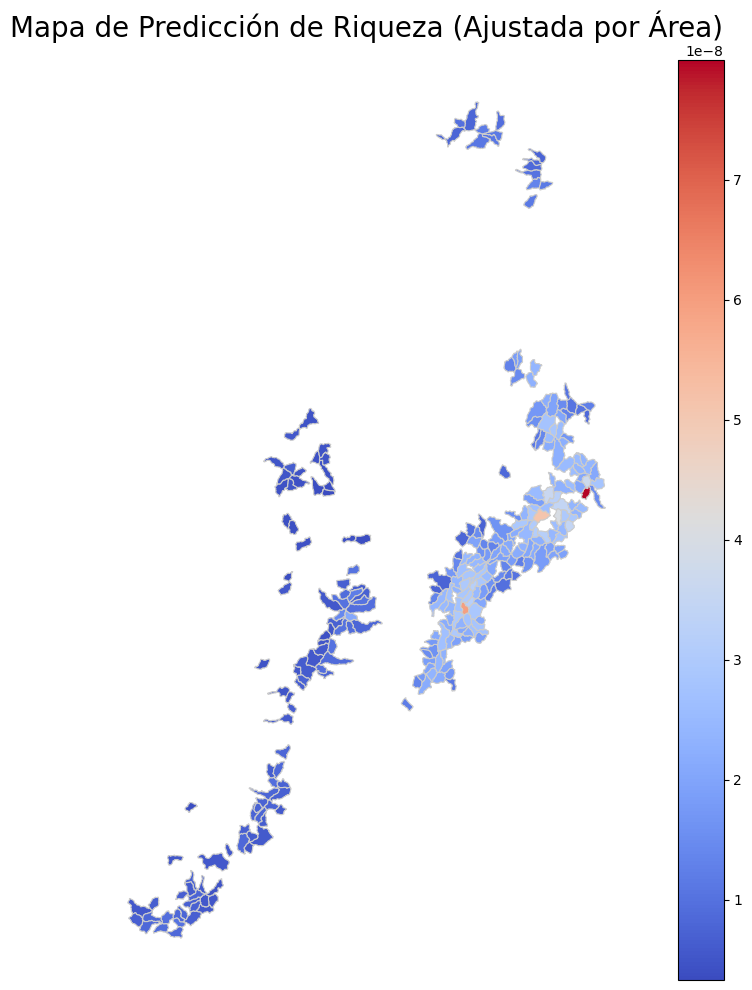

In [23]:
import matplotlib.pyplot as plt

# Obtener las predicciones del modelo con offset
y_pred_freq_offset = poisson_model_offset.predict(X)

# Añadir las predicciones al GeoDataFrame
df['predicted_species_offset'] = y_pred_freq_offset

# Calcular la diferencia entre el valor real y la predicción
df['difference_species_offset'] = df['num_species'] - df['predicted_species_offset']

# Graficar el mapa con los valores de predicción ajustados por área
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
df.plot(column='predicted_species_offset', cmap='coolwarm',
             linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

ax.set_title('Mapa de Predicción de Riqueza (Ajustada por Área)', fontsize=20)
ax.set_axis_off()
plt.tight_layout()
plt.show()


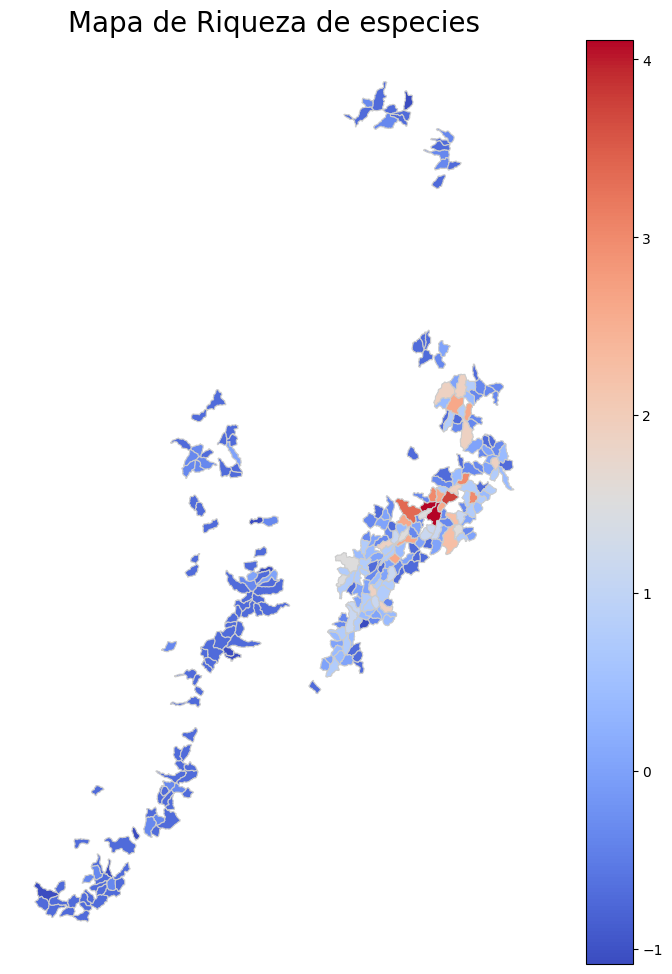

In [22]:
# Graficar el mapa con los valores de predicción ajustados por área
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
df.plot(column='num_species_std', cmap='coolwarm',
             linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

ax.set_title('Mapa de Riqueza de especies', fontsize=20)
ax.set_axis_off()
plt.tight_layout()
plt.show()

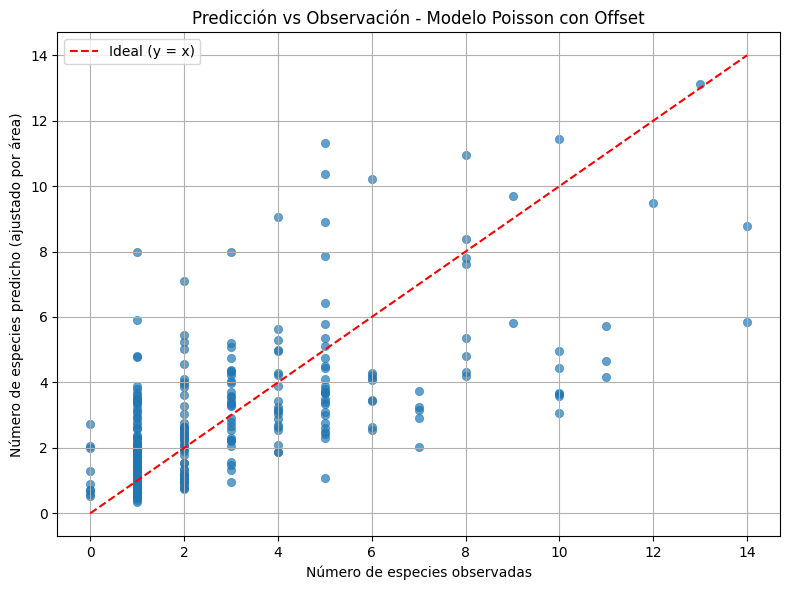

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Valores reales (observados)
y_obs = df['num_species']

# Valores predichos
y_pred = poisson_model_offset.predict(X, offset=offset)


# Crear gráfico de dispersión
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_obs, y=y_pred, alpha=0.7, edgecolor=None)
plt.plot([y_obs.min(), y_obs.max()], [y_obs.min(), y_obs.max()], color='red', linestyle='--', label='Ideal (y = x)')
plt.xlabel('Número de especies observadas')
plt.ylabel('Número de especies predicho (ajustado por área)')
plt.title('Predicción vs Observación - Modelo Poisson con Offset')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
